In [2]:
import vtk
from vtk import vtkXMLUnstructuredGridReader
from vtk.util.numpy_support import vtk_to_numpy
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.colors as mcolors
from scipy.spatial import KDTree
import pygmt
import pandas as pd
import importlib
from scipy.signal import savgol_filter
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
import matplotlib.patheffects as pe

os.chdir("../postprocessing_scripts/")
import parallel_curves
import slab_hydration
importlib.reload(slab_hydration)

os.chdir("../main_figures/")

In [3]:
def cartesian_to_spherical(x, y, z):
    """
    Takes an x, y, z and converts it to spherical coordinates. Returns r, theta, phi
    """
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = 90 - np.rad2deg( np.arccos( z / (np.sqrt(x**2 + y**2 + z**2)) ) )
    phi =  np.sign(y) * np.rad2deg(np.arccos( x / np.sqrt(x**2 + y**2) ))
    phi[np.where(phi < 0)] = phi[np.where(phi < 0)] + 360
    phi[np.where(phi == 0)] = 180
    
    return r, phi, theta

def spherical_to_global_cartesian(r, phi, theta):
    """
    Takes spherical coordinates r, theta, and phi and converts to Cartesian coordinates.
    Returns x, y, z
    """
    x = r * np.sin(np.deg2rad(90 - theta)) * np.cos(np.deg2rad(phi))
    y = r * np.sin(np.deg2rad(90 - theta)) * np.sin(np.deg2rad(phi))
    z = r * np.cos(np.deg2rad(90 - theta))
    
    return x, y, z

def water_concentration_func(pressure, temperature, cutoff_pressure, lithology):
    """ 
    This function takes polynomials used to define the phase diagram for hydration of a bulk rock composition from Tian et al. 2019, as well as
    a temperature and pressure, and outputs the partition coefficient of the rock at the specified P-T conditions.
    
    lithology: A string that specifies which rock composition from Tian et al., 2019 is being used. Can either be: "sediment", "MORB", "gabbro", or "peridotite".
    cutoff_pressure: The pressure, in GPa, that defines the maximum allowed pressure to be used in the Tian parameterization. This is necessary because the polynomials break down at high pressures leading to infinite maximum bound water contents.
    pressure: The pressure, in GPa, of the given lithology
    temperature: The temperature, in K, of the given lithology
    """
    
    # The polynomials defined in Tian et al., 2019 break down above certain pressures. If the input pressure is above this pressure,
    # set it to the highest pressure where the polynomials do NOT breakdown
    if lithology == "sediment":
        H2O_LR_poly = np.array([-2.03283, 10.8186, -21.2119, 18.3351, -6.48711, 8.32459])
        H2O_c_sat_poly = np.array([-0.150662, 0.301807, 1.01867])
        H2O_Td_poly = np.array([2.83277, -24.7593, 85.9090, 524.898])
        
    if lithology == "gabbro":
        H2O_LR_poly = np.array([-1.81745, 7.67198, -10.8507, 5.09329, 8.14519])
        H2O_c_sat_poly = np.array([-0.0176673, 0.0893044, 1.52732])
        H2O_Td_poly = np.array([-1.72277, 20.5898, 637.517])
        if pressure > cutoff_pressure:
            pressure = cutoff_pressure
            
    if lithology == "MORB":
        H2O_LR_poly = np.array([-1.78177, 7.50871, -10.4840, 5.19725, 7.96365])
        H2O_c_sat_poly = np.array([0.0102725, -0.115390, 0.324452, 1.41588])
        H2O_Td_poly = np.array([-3.81280, 22.7809, 638.049])
        if pressure > cutoff_pressure:
            pressure = cutoff_pressure
            
    if lithology == "peridotite":
        H2O_LR_poly = np.array([-19.0609, 168.983, -630.032, 1281.84, -1543.14, 1111.88, -459.142, 95.4143, 1.97246])
        H2O_c_sat_poly = np.array([0.00115628, 2.42179])
        H2O_Td_poly = np.array([-15.4627, 94.9716, 636.603])
        if pressure > cutoff_pressure:
            pressure = cutoff_pressure

    # Initialize the variables
    inv_pressure = 1/pressure
    ln_LR_val = 0
    ln_c_sat_val = 0
    Td_val = 0

    # Calculate the values for LR, c_sat, and Td
    for i in range(len(H2O_LR_poly)):
        ln_LR_val += H2O_LR_poly[i] * (inv_pressure**(len(H2O_LR_poly) - 1 - i))

    for j in range(len(H2O_c_sat_poly)):
        if lithology == "sediment":
            ln_c_sat_val += H2O_c_sat_poly[j] * (np.log10(pressure)**(len(H2O_c_sat_poly) - 1 - j))
            
        else:
            ln_c_sat_val += H2O_c_sat_poly[j] * (pressure**(len(H2O_c_sat_poly) - 1 - j))

    for k in range(len(H2O_Td_poly)):
        Td_val += H2O_Td_poly[k] * (pressure**(len(H2O_Td_poly) - 1 - k))

    LR_val = np.exp(ln_LR_val)
    c_sat_val = np.exp(ln_c_sat_val)

    # Calculate the partition coefficient (amount of water that can be stored in the rock)
    partition_coeff = c_sat_val * np.exp(LR_val * (1/temperature - 1/Td_val))
    return partition_coeff

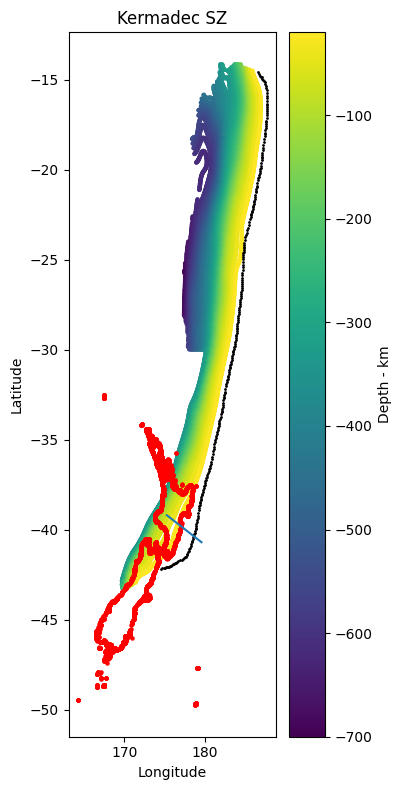

In [4]:
data_dir_path = "../data/"
coast_arr = np.loadtxt(fname=data_dir_path + "coastline.txt")
slab2_cont = np.loadtxt(fname=data_dir_path + "slab2_tonga.in", delimiter='\t', comments='>', dtype=float)

slab2_contours = np.array(sorted(slab2_cont, key=lambda x: x[1], reverse=True))
trench_contour = data = np.loadtxt(fname=data_dir_path + "trench_contour.csv", delimiter=',')[0:270]

lon_lat_slice = np.array([[179.57, -40.7], \
                          [175.27, -39.2]])

plt.figure(dpi=100, figsize=(4, 8))
plt.title('Kermadec SZ')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.scatter(slab2_contours[:,0], slab2_contours[:,1], c=slab2_contours[:,2], s = 5)
plt.colorbar(label = 'Depth - km')


plt.plot(lon_lat_slice[:, 0], lon_lat_slice[:, 1])

plt.scatter(trench_contour[:, 0], trench_contour[:, 1], s=1, c='black')
plt.scatter(coast_arr[:, 0], coast_arr[:, 1], s = 5, c='red')
plt.tight_layout()
plt.show()

In [5]:
T_range_vals = np.arange(100.0, 1250.0 + 1.0, 1.0) + 273 # K
P_range_vals = np.arange(0.5, 15.0 + 0.025, 0.025) # GP

# max_water_contents = np.array([0.033, 0.055, 0.055, 0.11]) * 100 # wt%
max_water_contents = np.array([0.033, 0.03, 0.008, 0.02]) * 100 # wt%
cutoff_pressures = np.array([20, 16, 26, 10])
lithology_strings = np.array(["sediment", "MORB", "gabbro", "peridotite"], dtype=str)

T_mesh, P_mesh = np.meshgrid(T_range_vals, P_range_vals)
sed_H2O = T_mesh * 0
MORB_H2O = T_mesh * 0
gabbro_H2O = T_mesh * 0
perid_H2O = T_mesh * 0

for k in range(len(max_water_contents)):
    for i in range(len(T_mesh)):
        for j in range(len(T_mesh[i])):
            
            water_at_point = water_concentration_func(P_mesh[i][j], T_mesh[i][j], 
                                                      cutoff_pressures[k], lithology=lithology_strings[k])

            if k == 0:
                if water_at_point > max_water_contents[k]:
                    sed_H2O[i][j] = max_water_contents[k]
                else:
                    sed_H2O[i][j] = water_at_point

            if k == 1:
                if water_at_point > max_water_contents[k]:
                    MORB_H2O[i][j] = max_water_contents[k]
                else:
                    MORB_H2O[i][j] = water_at_point

            if k == 2:
                if water_at_point > max_water_contents[k]:
                    gabbro_H2O[i][j] = max_water_contents[k]
                else:
                    gabbro_H2O[i][j] = water_at_point

            if k == 3:
                if water_at_point > max_water_contents[k]:
                    perid_H2O[i][j] = max_water_contents[k]
                else:
                    perid_H2O[i][j] = water_at_point

In [6]:
# sol_dir_path = "/Users/danieldouglas/FINAL_SLABS/additional_tests/massive_tar/refine_crustal_2.5km_lithostatic/solution/"
sol_dir_path = "/Users/danieldouglas/FINAL_SLABS/additional_tests/variable_hydration/solution/"
solutions = np.sort(os.listdir( sol_dir_path ))

t_step = 0
pos_solution = np.empty(0)
litho_total = np.empty(0)
crust_total = np.empty(0)
T_raw_total = np.empty(0)
P_raw_total = np.empty(0)

for soln in solutions:
    if soln[-4:-1] == '.vt' and soln[9:14] == str(t_step).zfill(5):
        
        file_path = os.path.join(sol_dir_path, soln)
        reader = vtkXMLUnstructuredGridReader()
        reader.SetFileName(file_path)
        reader.Update()
        data = reader.GetOutput()
        points = data.GetPoints()
        x = vtk_to_numpy(points.GetData())
        litho = vtk_to_numpy(data.GetPointData().GetArray('Base_Subducting'))
        crust = vtk_to_numpy(data.GetPointData().GetArray('Crust'))
        T_raw = vtk_to_numpy(data.GetPointData().GetArray('T'))
        P_raw = vtk_to_numpy(data.GetPointData().GetArray('p'))

        if len(pos_solution) == 0 :
            pos_solution = x
        else:
            pos_solution = np.concatenate( (pos_solution, x) )
            
        litho_total = np.concatenate( (litho_total, litho) )
        T_raw_total = np.concatenate( (T_raw_total, T_raw) )
        P_raw_total = np.concatenate( (P_raw_total, P_raw) )
        crust_total = np.concatenate( (crust_total, crust) )
            

slab_indices = np.where( (litho_total >= 0.95) | (crust_total >= 0.95) )
slab_x = pos_solution[:, 0][slab_indices]
slab_y = pos_solution[:, 1][slab_indices]
slab_z = pos_solution[:, 2][slab_indices]
slab_P = P_raw_total[slab_indices]
slab_T = T_raw_total[slab_indices]
ASPECT_slab_r, ASPECT_slab_phi, ASPECT_slab_theta = cartesian_to_spherical(slab_x, slab_y, slab_z)
slabtree_unstructured = KDTree(np.c_[slab_x, slab_y, slab_z])

In [7]:
GNS_quakes = np.loadtxt(fname="../data/GNS_earthquakes.csv", delimiter=',', 
                        usecols=[4, 5, 7], skiprows=1)
quake_lon = GNS_quakes[:, 0]
quake_lon[quake_lon < 0] += 360
quake_lat = GNS_quakes[:, 1]
quake_r = 6371e3 - GNS_quakes[:, 2] * 1e3

quake_x, quake_y, quake_z = spherical_to_global_cartesian(quake_r, quake_lon, quake_lat)

min_radius_for_quakes = 5000e3
quake_x = quake_x[quake_r >= min_radius_for_quakes]
quake_y = quake_y[quake_r >= min_radius_for_quakes]
quake_z = quake_z[quake_r >= min_radius_for_quakes]

quake_T = np.zeros(len(quake_x))
quake_P = np.zeros(len(quake_x))
quake_KDTree = KDTree(np.c_[pos_solution[:, 0], pos_solution[:, 1], pos_solution[:, 2]])

for i in range(len(quake_T)):
    dd, ii = slabtree_unstructured.query([quake_x[i], quake_y[i], quake_z[i]], k=1)
    # dd, ii = quake_KDTree.query([quake_x[i], quake_y[i], quake_z[i]], k=1)
    if dd <= 10e3:
        quake_T[i] = T_raw_total[ii]
        quake_P[i] = P_raw_total[ii]

Starting profile number: 1
No lithostatic profiles
Finished profile number: 1



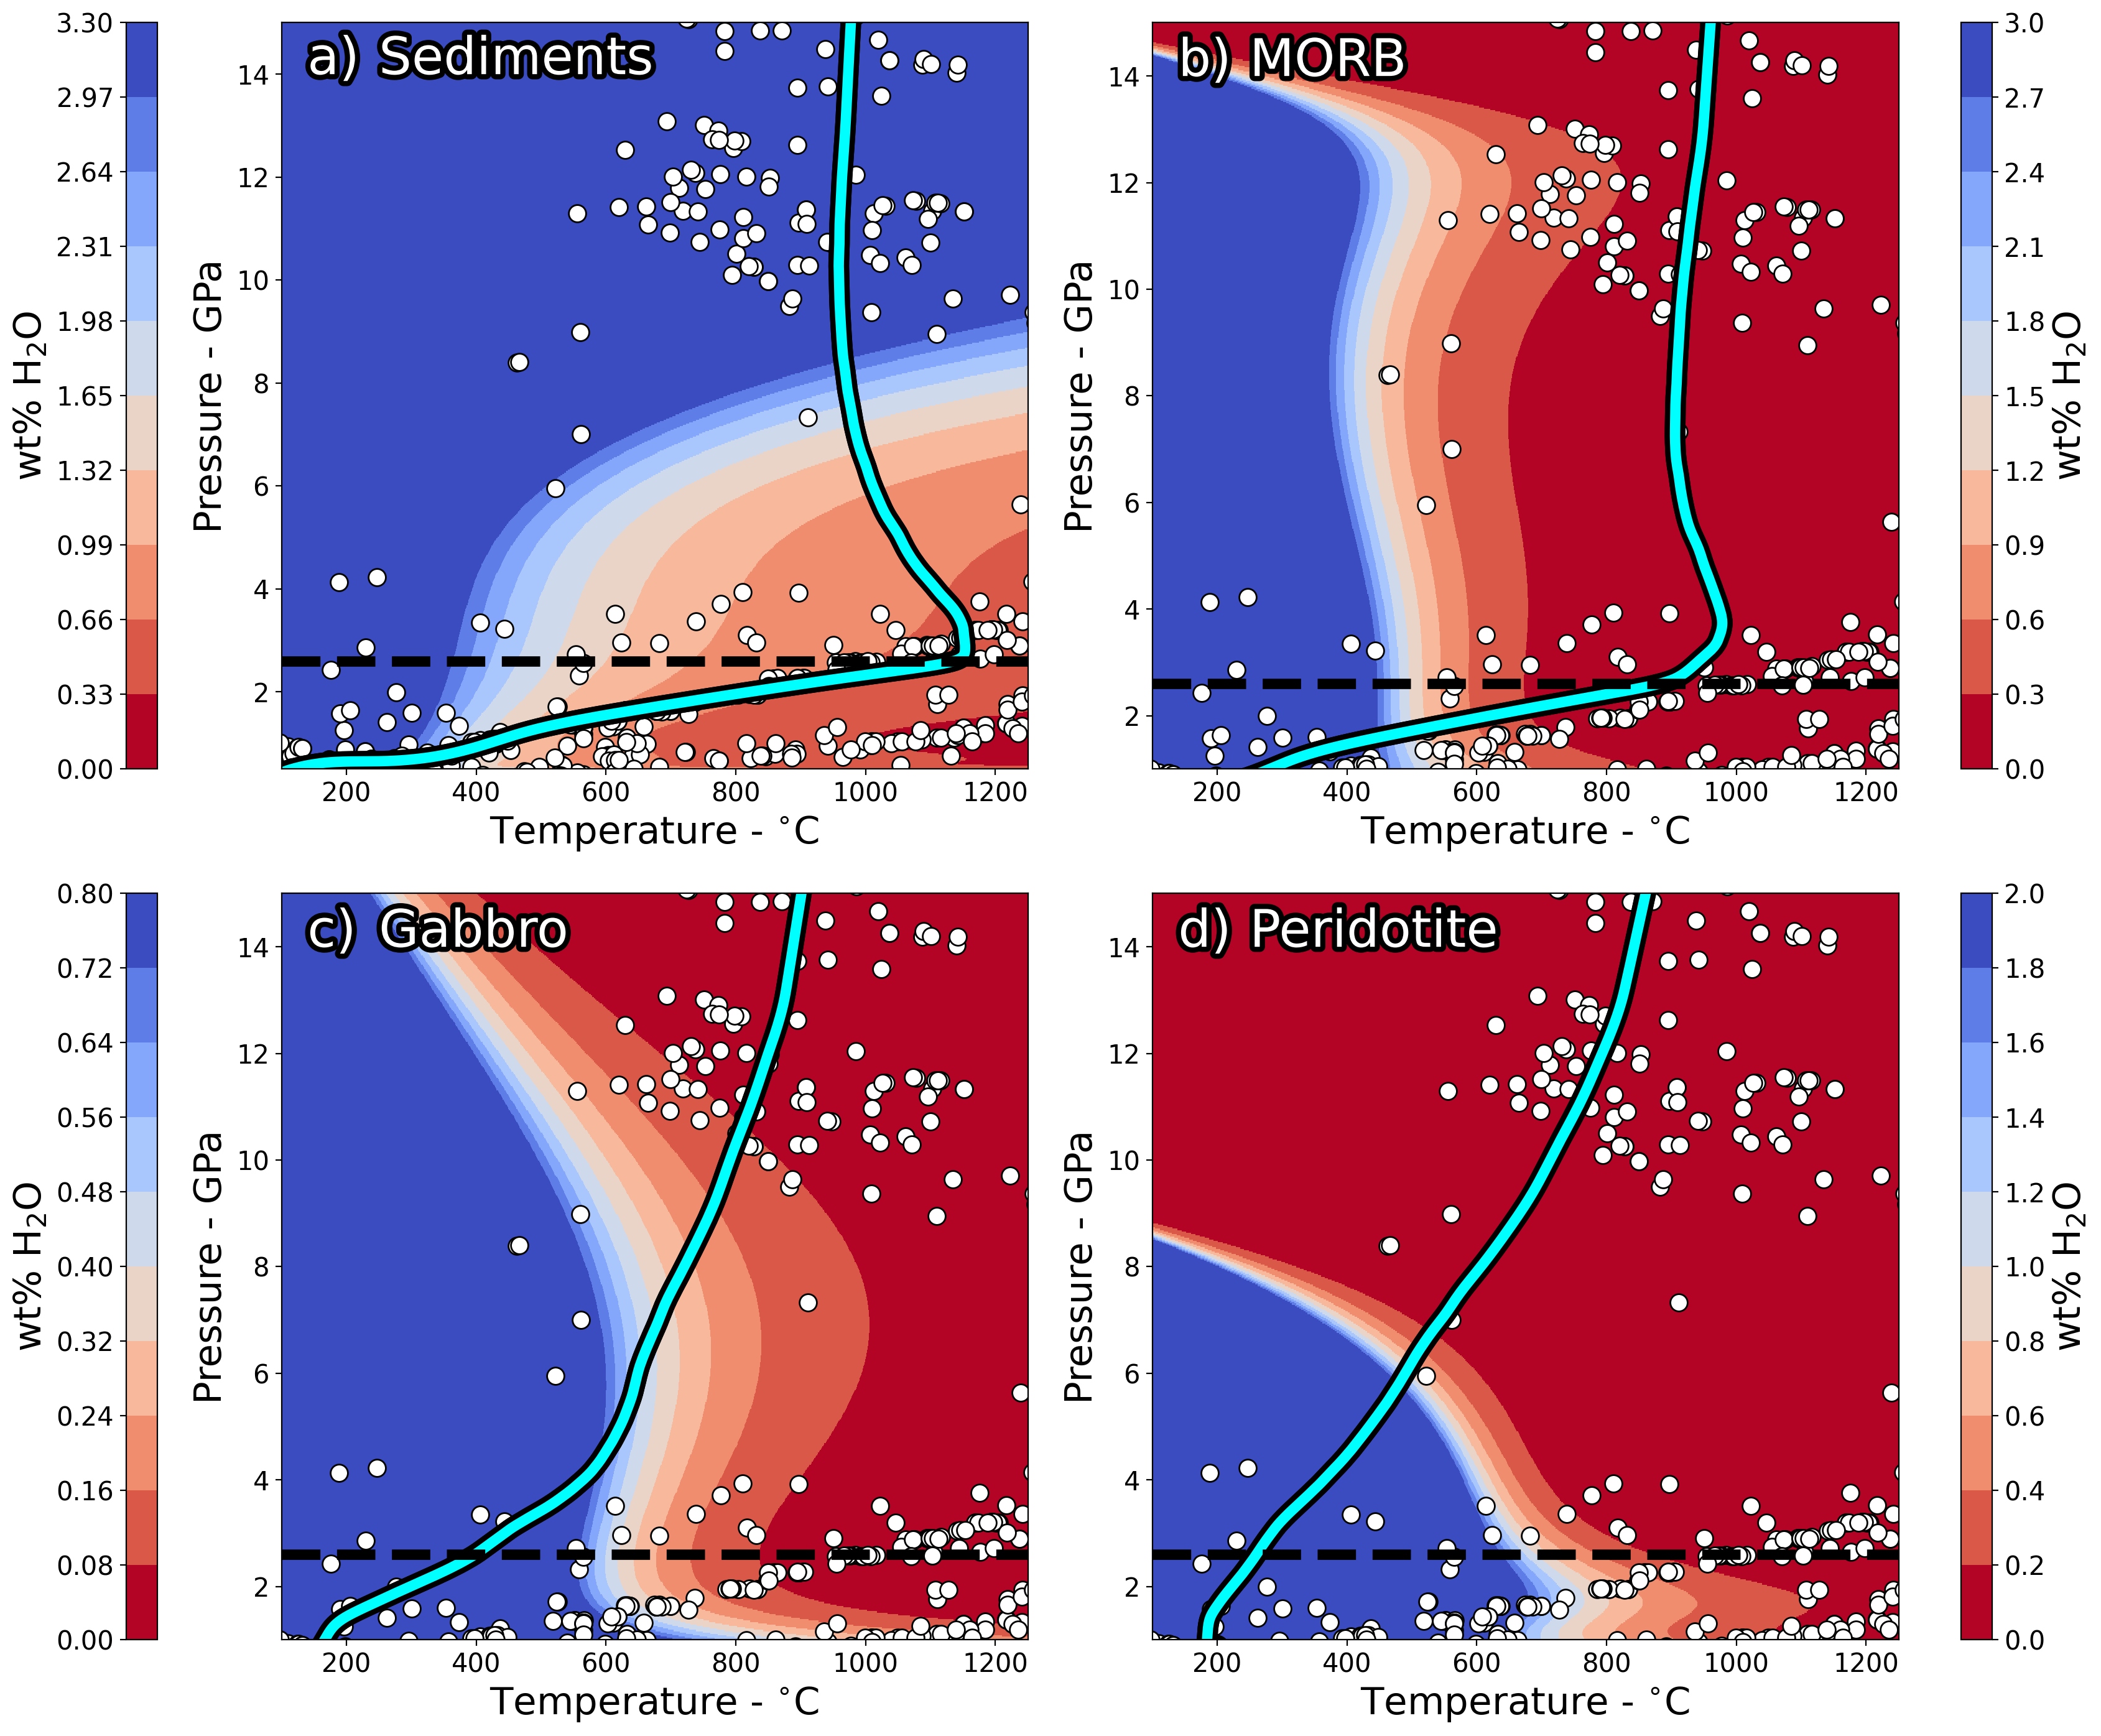

In [14]:
cutoff_distance = 250
max_cutoff_distance = 2500
cutoff_distance_interval = 250

radius_array = np.linspace(6371e3, 5871e3, 501)
base_depth = 0

window_size = 100
poly_order = 1

sediment_depth_range = np.array([0.75, 0.75])
MORB_depth_range = np.array([4.0, 4.0])
gabbro_depth_range = np.array([9.5, 9.5])
peridotite_depth_range = np.array([12.5, 12.5])

################################# INITIALIZE THE FIGURE #################################

south_color = "lime"
mid_color   = "magenta"
north_color = "lightgray"
color_array = np.array([south_color, mid_color, north_color], dtype=str)
cmap        = "coolwarm_r"

ymin, ymax = 1.0, 15
xmin, xmax = 100, 1250

axes_width, axes_height  = 6, 6
spacing = 1
cbar_width, cbar_spacing = 0.25, 0.5

fig_size_x = 2*axes_width + spacing
fig_size_y = 2*axes_height + spacing

fig = plt.figure(dpi=200, figsize=(fig_size_x, fig_size_y))


gab_box = [0, 0, 
           axes_width / fig_size_x, axes_height / fig_size_y]
per_box = [(axes_width + spacing) / fig_size_y, 0, 
           axes_width / fig_size_x, axes_height / fig_size_y]
sed_box = [0, (axes_height + spacing) / fig_size_y, 
           axes_width / fig_size_x, axes_height / fig_size_y]
MORB_box = [(axes_width + spacing) / fig_size_y, (axes_height + spacing) / fig_size_y, 
             axes_width / fig_size_x, axes_height / fig_size_y]

ax_sed = fig.add_axes(sed_box)
ax_MORB = fig.add_axes(MORB_box)
ax_gab = fig.add_axes(gab_box)
ax_per = fig.add_axes(per_box)


num_levels = 10
sed_levels = np.linspace(0, sed_H2O.max(), num_levels + 1)
MORB_levels = np.linspace(0, MORB_H2O.max(), num_levels + 1)
gab_levels = np.linspace(0, gabbro_H2O.max(), num_levels + 1)
per_levels = np.linspace(0, perid_H2O.max(), num_levels + 1)

num_ticks = 10
sed_ticks = np.linspace(0, sed_H2O.max(), num_ticks + 1)
MORB_ticks = np.linspace(0, MORB_H2O.max(), num_ticks + 1)
gab_ticks = np.linspace(0, gabbro_H2O.max(), num_ticks + 1)
per_ticks = np.linspace(0, perid_H2O.max(), num_ticks + 1)



cbar_sed = fig.add_axes([-2.5*cbar_spacing/fig_size_x, (axes_height + spacing)/fig_size_y, 
                         cbar_width/fig_size_x, axes_height/fig_size_y])

cbar_MORB = fig.add_axes([(2*axes_width + spacing + cbar_spacing)/fig_size_x, (axes_height + spacing)/fig_size_y, 
                          cbar_width/fig_size_x, axes_height/fig_size_y])

cbar_gab = fig.add_axes([-2.5*cbar_spacing/fig_size_x, 0, 
                         cbar_width/fig_size_x, axes_height/fig_size_y])

cbar_per = fig.add_axes([(2*axes_width + spacing + cbar_spacing)/fig_size_x, 0, 
                         cbar_width/fig_size_x, axes_height/fig_size_y])

########################################### THE SEDIMENTS PANEL ###########################################

norm = mcolors.BoundaryNorm(sed_levels, ncolors=plt.cm.viridis.N, clip=True)
pcm_sed = ax_sed.pcolormesh(T_mesh - 273, P_mesh, sed_H2O, cmap=cmap, norm=norm)

cbar = fig.colorbar(pcm_sed, cax=cbar_sed, ticks=sed_ticks, orientation='vertical')
cbar.set_label("wt% H$_2$O", fontsize=22)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_ticks_position('left')  
cbar.ax.yaxis.set_label_position('left')

########################################### THE MORB PANEL ###########################################

norm = mcolors.BoundaryNorm(MORB_levels, ncolors=plt.cm.viridis.N, clip=True)
pcm_MORB = ax_MORB.pcolormesh(T_mesh - 273, P_mesh, MORB_H2O, cmap=cmap, norm=norm)

cbar = fig.colorbar(pcm_MORB, cax=cbar_MORB, ticks=MORB_ticks, orientation='vertical')
cbar.set_label("wt% H$_2$O", fontsize=22)
cbar.ax.tick_params(labelsize=15)

########################################### THE GABBRO PANEL ###########################################

norm = mcolors.BoundaryNorm(gab_levels, ncolors=plt.cm.viridis.N, clip=True)
pcm_gab = ax_gab.pcolormesh(T_mesh - 273, P_mesh, gabbro_H2O, cmap=cmap, norm=norm)

cbar = fig.colorbar(pcm_gab, cax=cbar_gab, ticks=gab_ticks, orientation='vertical')
cbar.set_label("wt% H$_2$O", fontsize=22)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_ticks_position('left')  
cbar.ax.yaxis.set_label_position('left')

########################################### THE PERIDOTITE PANEL ###########################################

norm = mcolors.BoundaryNorm(per_levels, ncolors=plt.cm.viridis.N, clip=True)
pcm_per = ax_per.pcolormesh(T_mesh - 273, P_mesh, perid_H2O, cmap=cmap, norm=norm)

cbar = fig.colorbar(pcm_per, cax=cbar_per, ticks=per_ticks, orientation='vertical')
cbar.set_label("wt% H$_2$O", fontsize=22)
cbar.ax.tick_params(labelsize=15)

profiles_output_dir = "dehydration_mapview_profiles/"
plot_ind = 0

# PROFILE 32 MIGHT BE THE BEST CHOICE
list_of_profiles = np.array(["profile_00028.txt"])
# list_of_profiles = np.array(["profile_00008.txt", "profile_00020.txt", "profile_00032.txt"])
for prof in list_of_profiles:
    
    print("Starting profile number: " + str(plot_ind + 1))
    
    profile_file = np.loadtxt(fname=profiles_output_dir + "geographic/" + prof)
    
    lon_lat_slice = np.array([[profile_file[0][0], profile_file[0][1]], \
                              [profile_file[-1][0], profile_file[-1][1]]])

    profile = pygmt.project(center=[lon_lat_slice[0][0], lon_lat_slice[0][1]], endpoint=[lon_lat_slice[1][0], lon_lat_slice[1][1]], generate=1e3/1e3, unit=True).to_numpy()
    prof_lon = profile[:, 0]
    prof_lat = profile[:, 1]
    prof_dist = profile[:, 2]
    prof_lon[np.where(prof_lon < 0)] = prof_lon[np.where(prof_lon < 0)] + 360
    prof_lon[np.where(prof_lon == 0)] = 180
    
    slab_depth_vals = np.empty(0)
    slab_dist_vals = np.empty(0)
    slab_T_vals = np.empty(0)
    slab_P_vals = np.empty(0)
    
    for i in range(len(prof_lon)):
        for j in range(len(radius_array)):
            cutoff_distance = 250
            prof_x, prof_y, prof_z = spherical_to_global_cartesian(radius_array[j], prof_lon[i], prof_lat[i])
            found_closest_point = False
            ### I NEED TO TRY TO DO AN ADDITIONAL CHECK TO MAKE SURE THAT THE POINT THAT WE ARE CHOOSING FOR THE SLAB
            ### IS BELOW THE SURFACE!!! CHECK THE RADIUS OF THE SAMPLE PLOT AND THE RADIUS OF THE PROPSPECTIVE SLAB SURFACE
            ### POINT.
            dd, slab_idx = slabtree_unstructured.query([prof_x, prof_y, prof_z], k=1)
    
            dd_weight = dd / np.linalg.norm(dd)
            for k in range(int(max_cutoff_distance / cutoff_distance_interval)):
                if found_closest_point == False:
                    if dd <= cutoff_distance: 
                        if radius_array[j] < ASPECT_slab_r[slab_idx]:
                            found_closest_point = True
                            slab_dist_vals = np.append(slab_dist_vals, prof_dist[i])
                            slab_depth_vals = np.append(slab_depth_vals, (6371e3 - ASPECT_slab_r[slab_idx]) / 1e3 )
                            slab_T_vals = np.append(slab_T_vals, slab_T[slab_idx])
                            slab_P_vals = np.append(slab_P_vals, slab_P[slab_idx])

                    else:
                        cutoff_distance += cutoff_distance_interval
                else:
                    break

    min_x = np.min(slab_dist_vals)
    max_x = np.max(slab_dist_vals)
    dx = 0.25
    x_vals = np.arange(min_x, max_x + dx, dx)
    
    min_y = np.min(slab_depth_vals)
    max_y = np.max(slab_depth_vals)
    dy = 0.25
    y_vals = np.arange(min_y, max_y + dy, dy)
    
    grid_x, grid_y = np.meshgrid(x_vals, y_vals)
    
    grid_T_raw = griddata((slab_dist_vals, slab_depth_vals), slab_T_vals, (grid_x, grid_y), method='linear')
    slab_grid_x = np.ravel(grid_x)[np.where(np.isnan(np.ravel(grid_T_raw)) == False)]
    slab_grid_y = np.ravel(grid_y)[np.where(np.isnan(np.ravel(grid_T_raw)) == False)]
    
    slab_top_dist_test = np.empty(0)
    slab_top_depth_test = np.empty(0)
  
    for i in range(len(x_vals) - 1):
        dist_idx = np.where(np.ravel(slab_grid_x) == x_vals[i])
        slab_top_dist_test = np.append(slab_top_dist_test, x_vals[i])
        slab_top_depth_test = np.append(slab_top_depth_test, np.min(np.ravel(slab_grid_y)[dist_idx]))

        
    grid_T_raw = griddata((slab_dist_vals, slab_depth_vals), slab_T_vals, (grid_x, grid_y), method='nearest')
    grid_P_raw = griddata((slab_dist_vals, slab_depth_vals), slab_P_vals, (grid_x, grid_y), method='nearest')

    grid_T = gaussian_filter(grid_T_raw, sigma=15)
    grid_P = gaussian_filter(grid_P_raw, sigma=15)
    
    slab_grid_x = np.ravel(grid_x)[np.where(np.isnan(np.ravel(grid_T)) == False)]
    slab_grid_y = np.ravel(grid_y)[np.where(np.isnan(np.ravel(grid_T)) == False)]
    slab_grid_T = np.ravel(grid_T)[np.where(np.isnan(np.ravel(grid_T)) == False)]
    slab_grid_P = np.ravel(grid_P)[np.where(np.isnan(np.ravel(grid_T)) == False)]
    
    p_coeff = np.polyfit(slab_top_dist_test, slab_top_depth_test, 5)
    slab_top_depth_test = 0
    
    for p in range(len(p_coeff)):
        slab_top_depth_test += p_coeff[p] * slab_top_dist_test**(len(p_coeff) - 1 - p)
    
    ave_sed_depth = np.average(sediment_depth_range)
    ave_MORB_depth = np.average(MORB_depth_range)
    ave_gab_depth = np.average(gabbro_depth_range)
    ave_per_depth = np.average(peridotite_depth_range)
    
    # depths_for_curves = np.array([ave_sed_depth, ave_MORB_depth, ave_gab_depth, ave_per_depth])
    depths_for_curves = np.array([sediment_depth_range[0], sediment_depth_range[1],
                                  MORB_depth_range[0], MORB_depth_range[1],
                                  gabbro_depth_range[0], gabbro_depth_range[1],
                                  peridotite_depth_range[0], peridotite_depth_range[1]])
        
    parallel_slab_dist = np.zeros(len(depths_for_curves), dtype=object)
    parallel_slab_depth = np.zeros(len(depths_for_curves), dtype=object)
    
    # Draw parallel lines to the slab top curve
    for i in range(len(depths_for_curves)):
        res = parallel_curves.parallel_curves(slab_top_dist_test, slab_top_depth_test, d=base_depth + depths_for_curves[i], make_plot=False, flag1=False)
        parallel_slab_dist[i] = res['x_inner']
        parallel_slab_depth[i] = res['y_inner']

        
    slab_tree = KDTree(np.c_[np.ravel(slab_grid_x), 
                             np.ravel(slab_grid_y)])

    profile_pressure = np.zeros(len(parallel_slab_dist), dtype=object)
    profile_temperature = np.zeros(len(parallel_slab_dist), dtype=object)
    
    # Extract the slab P-T along each of the parallel profiles
    for i in range(len(parallel_slab_dist)):
        profile_pressure[i] = np.zeros(len(parallel_slab_dist[i]))
        profile_temperature[i] = np.zeros(len(parallel_slab_dist[i]))
        
        for j in range(len(parallel_slab_dist[i])):
            dd, ii = slab_tree.query([parallel_slab_dist[i][j], parallel_slab_depth[i][j]], k=4)
            profile_pressure[i][j] = np.average(np.ravel(slab_grid_P)[ii], weights=1/dd)
            profile_temperature[i][j] = np.average(np.ravel(slab_grid_T)[ii], weights=1/dd)
    
        profile_pressure[i] = savgol_filter(profile_pressure[i], window_length=window_size, polyorder=poly_order)
        profile_temperature[i] = savgol_filter(profile_temperature[i], window_length=window_size, polyorder=poly_order)

    if "litho" in sol_dir_path:
        litho_sediment_T1 = profile_temperature[0]
        litho_MORB_T1 = profile_temperature[2]
        litho_gabbro_T1 = profile_temperature[4]
        litho_peridotite_T1 = profile_temperature[6]
    
        litho_sediment_T2 = profile_temperature[1]
        litho_MORB_T2 = profile_temperature[3]
        litho_gabbro_T2 = profile_temperature[5]
        litho_peridotite_T2 = profile_temperature[7]
        
        litho_sediment_P1 = profile_pressure[0]
        litho_MORB_P1 = profile_pressure[2]
        litho_gabbro_P1 = profile_pressure[4]
        litho_peridotite_P1 = profile_pressure[6]
    
        litho_sediment_P2 = profile_pressure[1]
        litho_MORB_P2 = profile_pressure[3]
        litho_gabbro_P2 = profile_pressure[5]
        litho_peridotite_P2 = profile_pressure[7]

    else:
        sediment_T1 = profile_temperature[0]
        MORB_T1 = profile_temperature[2]
        gabbro_T1 = profile_temperature[4]
        peridotite_T1 = profile_temperature[6]
    
        sediment_T2 = profile_temperature[1]
        MORB_T2 = profile_temperature[3]
        gabbro_T2 = profile_temperature[5]
        peridotite_T2 = profile_temperature[7]
        
        sediment_P1 = profile_pressure[0]
        MORB_P1 = profile_pressure[2]
        gabbro_P1 = profile_pressure[4]
        peridotite_P1 = profile_pressure[6]
    
        sediment_P2 = profile_pressure[1]
        MORB_P2 = profile_pressure[3]
        gabbro_P2 = profile_pressure[5]
        peridotite_P2 = profile_pressure[7]

    try:
        ax_sed.plot(litho_sediment_T1 - 273, litho_sediment_P1 / 1e9, ls='-', c="black", lw=12)
        ax_MORB.plot(litho_MORB_T1 - 273, litho_MORB_P1 / 1e9, ls='-', c="black", lw=12)
        ax_gab.plot(litho_gabbro_T1 - 273, litho_gabbro_P1 / 1e9, ls='-', c="black", lw=12)
        ax_per.plot(litho_peridotite_T1 - 273, litho_peridotite_P1 / 1e9, ls='-', c="black", lw=12)
        
        ax_sed.plot(litho_sediment_T1 - 273, litho_sediment_P1 / 1e9, ls='--', c="lawngreen", lw=6)
        ax_MORB.plot(litho_MORB_T1 - 273, litho_MORB_P1 / 1e9, ls='--', c="lawngreen", lw=6)
        ax_gab.plot(litho_gabbro_T1 - 273, litho_gabbro_P1 / 1e9, ls='--', c="lawngreen", lw=6)
        ax_per.plot(litho_peridotite_T1 - 273, litho_peridotite_P1 / 1e9, ls='--', c="lawngreen", lw=6)
    
        ax_sed.plot(litho_sediment_T2 - 273, litho_sediment_P2 / 1e9, ls='-', c="black", lw=12)
        ax_MORB.plot(litho_MORB_T2 - 273, litho_MORB_P2 / 1e9, ls='-', c="black", lw=12)
        ax_gab.plot(litho_gabbro_T2 - 273, litho_gabbro_P2 / 1e9, ls='-', c="black", lw=12)
        ax_per.plot(litho_peridotite_T2 - 273, litho_peridotite_P2 / 1e9, ls='-', c="black", lw=12)
    
        ax_sed.plot(litho_sediment_T2 - 273, litho_sediment_P2 / 1e9, ls='--', c="lawngreen", lw=6)
        ax_MORB.plot(litho_MORB_T2 - 273, litho_MORB_P2 / 1e9, ls='--', c="lawngreen", lw=6)
        ax_gab.plot(litho_gabbro_T2 - 273, litho_gabbro_P2 / 1e9, ls='--', c="lawngreen", lw=6)
        ax_per.plot(litho_peridotite_T2 - 273, litho_peridotite_P2 / 1e9, ls='--', c="lawngreen", lw=6)

    except NameError:
        print("No lithostatic profiles")

    try:
        ax_sed.plot(sediment_T1 - 273, sediment_P1 / 1e9, ls='-', c="black", lw=12)
        ax_MORB.plot(MORB_T1 - 273, MORB_P1 / 1e9, ls='-', c="black", lw=12)
        ax_gab.plot(gabbro_T1 - 273, gabbro_P1 / 1e9, ls='-', c="black", lw=12)
        ax_per.plot(peridotite_T1 - 273, peridotite_P1 / 1e9, ls='-', c="black", lw=12)
        
        ax_sed.plot(sediment_T1 - 273, sediment_P1 / 1e9, ls='-', c="lawngreen", lw=6)
        ax_MORB.plot(MORB_T1 - 273, MORB_P1 / 1e9, ls='-', c="lawngreen", lw=6)
        ax_gab.plot(gabbro_T1 - 273, gabbro_P1 / 1e9, ls='-', c="lawngreen", lw=6)
        ax_per.plot(peridotite_T1 - 273, peridotite_P1 / 1e9, ls='-', c="lawngreen", lw=6)
    
        ax_sed.plot(sediment_T2 - 273, sediment_P2 / 1e9, ls='-', c="black", lw=12)
        ax_MORB.plot(MORB_T2 - 273, MORB_P2 / 1e9, ls='-', c="black", lw=12)
        ax_gab.plot(gabbro_T2 - 273, gabbro_P2 / 1e9, ls='-', c="black", lw=12)
        ax_per.plot(peridotite_T2 - 273, peridotite_P2 / 1e9, ls='-', c="black", lw=12)
    
        ax_sed.plot(sediment_T2 - 273, sediment_P2 / 1e9, ls='-', c="cyan", lw=6)
        ax_MORB.plot(MORB_T2 - 273, MORB_P2 / 1e9, ls='-', c="cyan", lw=6)
        ax_gab.plot(gabbro_T2 - 273, gabbro_P2 / 1e9, ls='-', c="cyan", lw=6)
        ax_per.plot(peridotite_T2 - 273, peridotite_P2 / 1e9, ls='-', c="cyan", lw=6)

    except NameError:
        print("No dynamic profiles")
    # sediment_T = profile_temperature[0]
    # MORB_T = profile_temperature[1]
    # gabbro_T = profile_temperature[2]
    # peridotite_T = profile_temperature[3]
    
    
    # sediment_P = profile_pressure[0]
    # MORB_P = profile_pressure[1]
    # gabbro_P = profile_pressure[2]
    # peridotite_P = profile_pressure[3]
    
    # ax_sed.plot(sediment_T - 273, sediment_P / 1e9, ls='-', c=color_array[plot_ind], lw=6)
    # ax_MORB.plot(MORB_T - 273, MORB_P / 1e9, ls='-', c=color_array[plot_ind], lw=6)
    # ax_gab.plot(gabbro_T - 273, gabbro_P / 1e9, ls='-', c=color_array[plot_ind], lw=6)
    # ax_per.plot(peridotite_T - 273, peridotite_P / 1e9, ls='-', c=color_array[plot_ind], lw=6)
    plot_ind += 1
    print("Finished profile number: " + str(plot_ind) + "\n")


ax_sed.text(140, 14, "a)", fontsize=30, color="white",
             path_effects=[pe.Stroke(linewidth=6, foreground="black"), pe.Normal()])
ax_sed.text(250, 14, "Sediments", fontsize=30, color="white",
             path_effects=[pe.Stroke(linewidth=6, foreground="black"), pe.Normal()])
ax_sed.set_xlim(xmin, xmax)
ax_sed.set_ylim(0.5, ymax)
ax_sed.set_xlabel("Temperature - $^{\circ}$C", fontsize=22)
ax_sed.set_ylabel("Pressure - GPa", fontsize=22)
ax_sed.tick_params(labelsize=15)
ax_sed.scatter(quake_T - 273, quake_P / 1e9, facecolor='white', edgecolor='black', s=100)
ax_sed.axhline(2.6, lw=6, ls='--', c='black')



ax_MORB.text(140, 14, "b)", fontsize=30, color="white",
             path_effects=[pe.Stroke(linewidth=6, foreground="black"), pe.Normal()])
ax_MORB.text(250, 14, "MORB", fontsize=30, color="white",
             path_effects=[pe.Stroke(linewidth=6, foreground="black"), pe.Normal()])
ax_MORB.set_xlim(xmin, xmax)
ax_MORB.set_ylim(ymin, ymax)
ax_MORB.set_xlabel("Temperature - $^{\circ}$C", fontsize=22)
ax_MORB.set_ylabel("Pressure - GPa", fontsize=22)
ax_MORB.tick_params(labelsize=15)
ax_MORB.scatter(quake_T - 273, quake_P / 1e9, facecolor='white', edgecolor='black', s=100)
ax_MORB.axhline(2.6, lw=6, ls='--', c='black')



ax_gab.text(140, 14, "c)", fontsize=30, color="white",
           path_effects=[pe.Stroke(linewidth=6, foreground="black"), pe.Normal()])
ax_gab.text(250, 14, "Gabbro", fontsize=30, color="white",
           path_effects=[pe.Stroke(linewidth=6, foreground="black"), pe.Normal()])
ax_gab.set_xlim(xmin, xmax)
ax_gab.set_ylim(ymin, ymax)
ax_gab.set_xlabel("Temperature - $^{\circ}$C", fontsize=22)
ax_gab.set_ylabel("Pressure - GPa", fontsize=22)
ax_gab.tick_params(labelsize=15)
ax_gab.scatter(quake_T - 273, quake_P / 1e9, facecolor='white', edgecolor='black', s=100)
ax_gab.axhline(2.6, lw=6, ls='--', c='black')



ax_per.text(140, 14, "d)", fontsize=30, color="white",
           path_effects=[pe.Stroke(linewidth=6, foreground="black"), pe.Normal()])
ax_per.text(250, 14, "Peridotite", fontsize=30, color="white",
           path_effects=[pe.Stroke(linewidth=6, foreground="black"), pe.Normal()])
ax_per.set_xlim(xmin, xmax)
ax_per.set_ylim(ymin, ymax)
ax_per.set_xlabel("Temperature - $^{\circ}$C", fontsize=22)
ax_per.set_ylabel("Pressure - GPa", fontsize=22)
ax_per.tick_params(labelsize=15)
ax_per.scatter(quake_T - 273, quake_P / 1e9, facecolor='white', edgecolor='black', s=100)
ax_per.axhline(2.6, lw=6, ls='--', c='black')

plt.savefig("phase_diagrams.png", bbox_inches = "tight")
plt.show()